# **Principal Component Analysis from Scratch**

## 0.ライブラリのインポートとデータの生成

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=42)

## 1.アルゴリズム

データの次元を減らしながら、重要な情報を残すアルゴリズム。

### 1.1.主成分分析

データの分散が最大になる方向（主成分）に新たな軸を取り、上位k個の主成分だけを残すことで次元を削減する。

### 1.2.共分散行列

各特徴量の分散と特徴量間の共分散をまとめた行列であり、以下の式で表される。  
$$C = \frac{1}{n}X^TX$$
対角成分が各特徴量の分散、非対角成分が特徴量間の共分散である。  
PCAでは、固有ベクトルの向きが分散が最大となる向きと考える。  
$$\text{Var}(z) = v^T C v$$
$$v^TCv = v^T(\lambda v) = \lambda$$
固有ベクトルの大きさを1としたときこの式が成り立つため、固有ベクトルの向きの分散は固有値であると言える。

In [10]:
def fit(X, n_components):
  mean = np.mean(X, axis=0)
  std = np.std(X, axis=0)
  X_std = (X - mean) / std
  n = X_std.shape[0]
  cov_matrix = X_std.T @ X_std / n
  eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
  sorted_indices = np.argsort(eigenvalues)[::-1]
  components = eigenvectors[:, sorted_indices[:n_components]]

  return components, mean, std, eigenvalues[sorted_indices]

def transform(X, components, mean, std):
  X_std = (X - mean) / std
  return X_std @ components

## 2.モデルの可視化

### 2.1.元データと主成分の方向

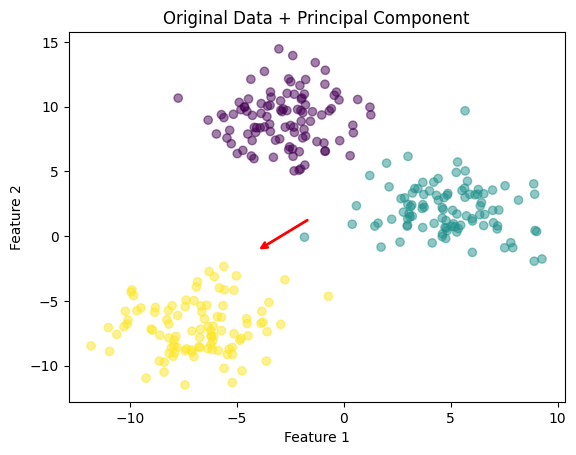

In [11]:
components, mean, std, eigenvalues = fit(X, n_components=1)

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
origin = mean
for comp, eigval in zip(components.T, eigenvalues[:1]):
  plt.annotate('', xy=origin + comp * np.sqrt(eigval) * 3, xytext=origin, arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.title("Original Data + Principal Component")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 2.2.次元削減後のデータ

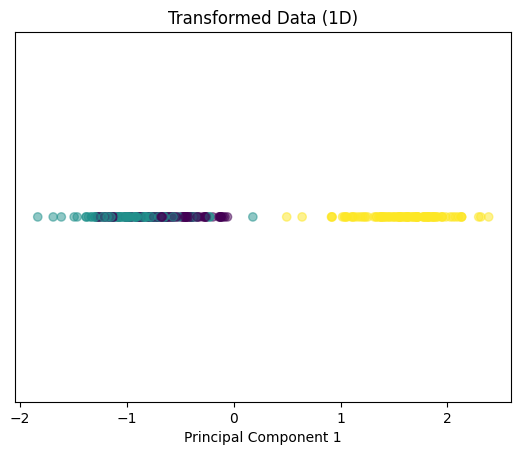

In [12]:
X_transformed = transform(X, components, mean, std)

plt.scatter(X_transformed, np.zeros_like(X_transformed), c=y, alpha=0.5)
plt.title("Transformed Data (1D)")
plt.xlabel("Principal Component 1")
plt.yticks([])
plt.show()

## 3.検証

### 3.1.累積寄与率

各主成分がデータ全体の分散の何%を説明しているかを寄与率と呼ぶ。
$$\text{寄与率} = \frac{\lambda_k}{\sum_{i=1}^{n}\lambda_i}$$
寄与率を累積したものが累積寄与率であり、上位k個の主成分でデータの情報の何%をカバーできるかを表す。

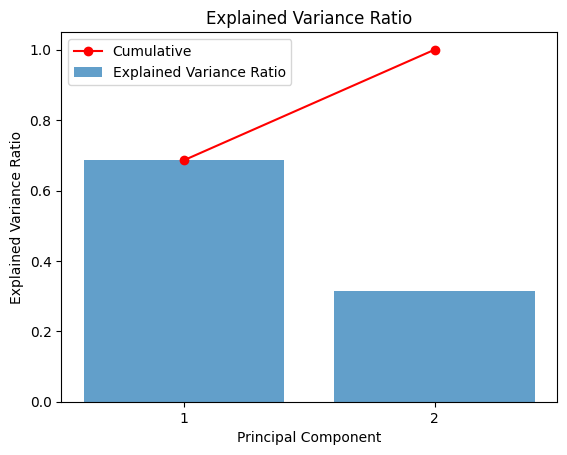

In [13]:
components_all, _, _, eigenvalues_all = fit(X, n_components=2)
explained_variance_ratio = eigenvalues_all / np.sum(eigenvalues_all)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.bar([1, 2], explained_variance_ratio, alpha=0.7, label='Explained Variance Ratio')
plt.plot([1, 2], cumulative_variance, marker='o', color='red', label='Cumulative')
plt.xticks([1, 2])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio")
plt.legend()
plt.show()

### 3.2.次元削減前後の比較

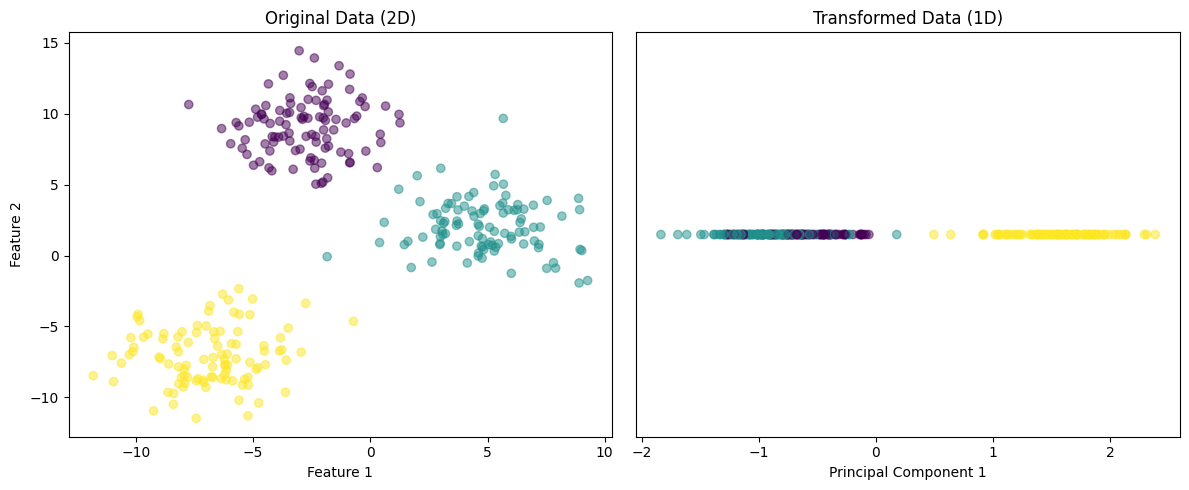

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
axes[0].set_title("Original Data (2D)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_transformed, np.zeros_like(X_transformed), c=y, alpha=0.5)
axes[1].set_title("Transformed Data (1D)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()